In [165]:
from utils import *
import matplotlib.pyplot as plt
from scipy.io import loadmat
import numpy as np


## Data Exploration

### Load dataset and inspect contents

In [166]:
data = loadmat("PiecewiseSparse.mat")

A = data["A"]
Xf = data["FinalState"]

print("A shape :", A.shape)
print("Xf shape:", Xf.shape)

A shape : (25, 25)
Xf shape: (1000, 25)


### Desired States

In [167]:
print("Final-state statistics")
print("----------------------")
print("Min :", Xf.min())
print("Max :", Xf.max())
print("Mean:", Xf.mean())
print("Std :", Xf.std())

Final-state statistics
----------------------
Min : -4.232539423129264
Max : 3.9976778030754976
Mean: -0.0015596130427643358
Std : 1.0029575396312087


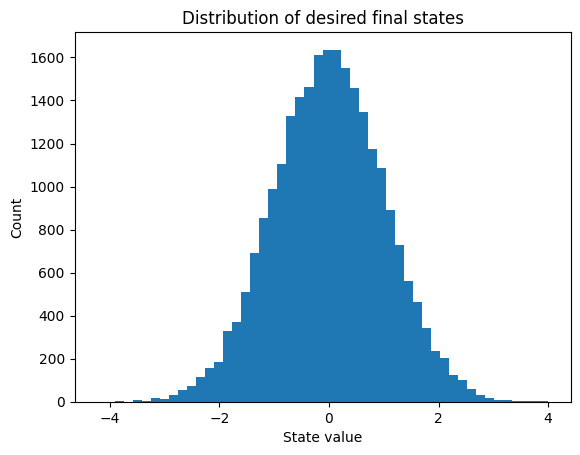

In [168]:
plt.hist(Xf.flatten(), bins=50)
plt.xlabel("State value")
plt.ylabel("Count")
plt.title("Distribution of desired final states")
plt.show()

### Network Matrix A

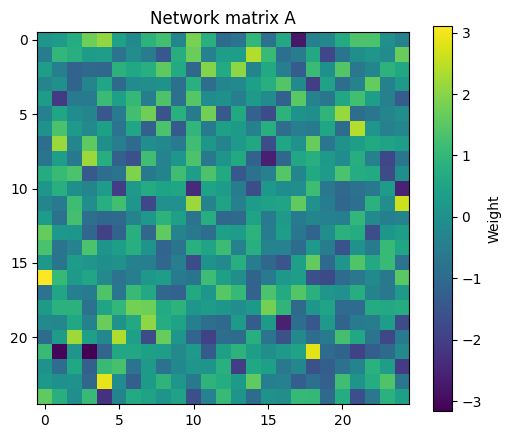

In [169]:
plt.figure(figsize=(6,5))
plt.imshow(A)
plt.colorbar(label="Weight")
plt.title("Network matrix A")
plt.show()

### Dynamics Diagnostics

In [170]:
eigvals = np.linalg.eigvals(A)

print("Spectral radius:", np.max(np.abs(eigvals)))
print("Nonzero entries:", np.count_nonzero(A))

Spectral radius: 6.0777908165333985
Nonzero entries: 625


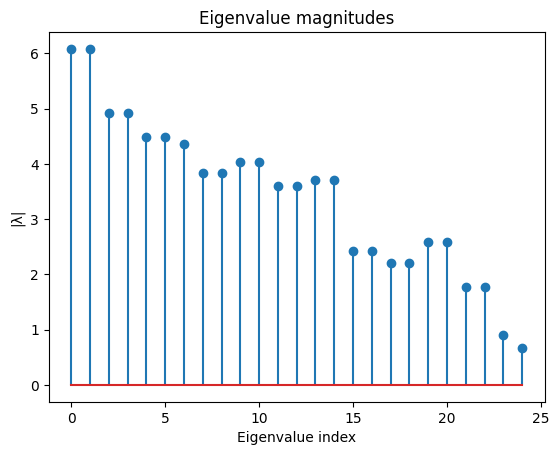

In [171]:
plt.stem(np.abs(eigvals))
plt.xlabel("Eigenvalue index")
plt.ylabel("|λ|")
plt.title("Eigenvalue magnitudes")
plt.show()

### Controllability matrix conditioning

In [172]:
N = A.shape[0]

C = np.hstack([
    np.linalg.matrix_power(A, N-1-k)
    for k in range(N)
])

s = np.linalg.svd(C, compute_uv=False)

print("Rank:", np.linalg.matrix_rank(C))
print("Condition number:", s[0]/s[-1])

Rank: 21
Condition number: 7.89726718989214e+16


## Problem Formulation and Numerical Preprocessing

### Define horizon and target

In [173]:
N = A.shape[0]
T = N

x0 = np.zeros(N)
Y = Xf.copy()   # since x0 = 0, y = xd = Xf

print("N:", N)
print("T:", T)
print("Y shape:", Y.shape)

N: 25
T: 25
Y shape: (1000, 25)


### Build controllability matrix

In [174]:
def build_C(A, T):
    return np.hstack([
        np.linalg.matrix_power(A, T - 1 - k)
        for k in range(T)
    ])

C = build_C(A, T)

print("C shape:", C.shape)

C shape: (25, 625)


### Check Conditioning of C

In [175]:
svals_C = np.linalg.svd(C, compute_uv=False)

print("Raw controllability matrix")
print("--------------------------")
print("Rank:", np.linalg.matrix_rank(C))
print("Largest singular value :", svals_C[0])
print("Smallest singular value:", svals_C[-1])
print("Condition number:", svals_C[0] / svals_C[-1])
print("Max absolute entry:", np.max(np.abs(C)))

Raw controllability matrix
--------------------------
Rank: 21
Largest singular value : 1.117419684785262e+19
Smallest singular value: 141.49447624305637
Condition number: 7.89726718989214e+16
Max absolute entry: 1.997236987192452e+18


### Column normalization / coordinate change

In [176]:
col_norms = np.linalg.norm(C, axis=0)
safe_col_norms = np.maximum(col_norms, 1e-12)

C_tilde = C / safe_col_norms[None, :]

print("Column norm range before normalization:")
print("min:", col_norms.min())
print("max:", col_norms.max())

print("\nColumn norm range after normalization:")
print("min:", np.linalg.norm(C_tilde, axis=0).min())
print("max:", np.linalg.norm(C_tilde, axis=0).max())

Column norm range before normalization:
min: 1.0
max: 4.517338266030377e+18

Column norm range after normalization:
min: 0.9999999999999997
max: 1.0000000000000002


### Compare raw and normalised matrices

In [177]:
def matrix_diagnostics(M, name):
    svals = np.linalg.svd(M, compute_uv=False)

    print(name)
    print("-" * len(name))
    print("Rank:", np.linalg.matrix_rank(M))
    print("Largest singular value :", svals[0])
    print("Smallest singular value:", svals[-1])
    print("Condition number:", svals[0] / svals[-1])
    print()

matrix_diagnostics(C, "Raw C")
matrix_diagnostics(C_tilde, "Normalized C_tilde")

Raw C
-----
Rank: 21
Largest singular value : 1.117419684785262e+19
Smallest singular value: 141.49447624305637
Condition number: 7.89726718989214e+16

Normalized C_tilde
------------------
Rank: 25
Largest singular value : 16.701834441490455
Smallest singular value: 1.0017891014191826
Condition number: 16.672006530945318



### Least-squares sanity check

In [178]:
def ls_sanity_check(C, C_tilde, safe_col_norms, Y, num_tests=10):
    raw_errors = []
    normalized_errors = []

    for i in range(num_tests):
        y = Y[i]

        u_raw, *_ = np.linalg.lstsq(C, y, rcond=None)
        y_hat_raw = C @ u_raw
        raw_errors.append(np.linalg.norm(y - y_hat_raw) / np.linalg.norm(y))

        z, *_ = np.linalg.lstsq(C_tilde, y, rcond=None)
        u = z / safe_col_norms
        y_hat = C @ u
        normalized_errors.append(np.linalg.norm(y - y_hat) / np.linalg.norm(y))

    print("Least-squares sanity check")
    print("--------------------------")
    print("Raw C mean error:", np.mean(raw_errors))
    print("Normalized mean error:", np.mean(normalized_errors))
    print("Raw C max error:", np.max(raw_errors))
    print("Normalized max error:", np.max(normalized_errors))

ls_sanity_check(C, C_tilde, safe_col_norms, Y)

Least-squares sanity check
--------------------------
Raw C mean error: 0.38820205544867326
Normalized mean error: 3.2388988367838575e-15
Raw C max error: 0.6757882045306833
Normalized max error: 6.954611950803341e-15


## OMP -- baseline

### OMP implementation

In [179]:
def omp(Phi, y, K):
    """
    Standard OMP with fixed global sparsity K.
    Used as a relaxed baseline with K = T*s.
    """
    m, n = Phi.shape

    residual = y.copy()
    support = []
    residual_norms = [np.linalg.norm(residual)]

    z_hat = np.zeros(n)

    for _ in range(K):
        corr = Phi.T @ residual

        if support:
            corr[support] = 0

        idx = np.argmax(np.abs(corr))
        support.append(idx)

        Phi_S = Phi[:, support]
        z_S, *_ = np.linalg.lstsq(Phi_S, y, rcond=None)

        residual = y - Phi_S @ z_S
        residual_norms.append(np.linalg.norm(residual))

    z_hat[support] = z_S

    return z_hat, support, residual_norms

### Evaluate OMP over all targets

In [180]:
def evaluate_omp(Xf, C, C_tilde, safe_col_norms, s, N=25, T=25):
    """
    OMP uses the same total budget as the piecewise problem:
        K = T*s
    but does not enforce s nonzeros per block.
    """
    K = T * s

    errors = []
    energies = []
    U_hat = []

    for y in Xf:
        z_hat, _, _ = omp(C_tilde, y, K)

        u_hat = z_hat / safe_col_norms
        x_hat = C @ u_hat

        errors.append(np.linalg.norm(y - x_hat) / np.linalg.norm(y))
        energies.append(np.linalg.norm(u_hat))
        U_hat.append(u_hat)

    return {
        "errors": np.array(errors),
        "energies": np.array(energies),
        "U_hat": np.array(U_hat),
    }

### OMP sparsity sweep

In [181]:
s_values = [1, 2, 3, 4, 5]
omp_results = {}

for s in s_values:
    res = evaluate_omp(Xf, C, C_tilde, safe_col_norms, s, N=N, T=T)
    omp_results[s] = res

    print(f"\nOMP baseline, s={s}, K={T*s}")
    print("----------------------")
    print("Mean error :", res["errors"].mean())
    print("Median error:", np.median(res["errors"]))
    print("Max error  :", res["errors"].max())
    print("Mean energy:", res["energies"].mean())


OMP baseline, s=1, K=25
----------------------
Mean error : 1.4264949534931928e-15
Median error: 1.1105910798147115e-15
Max error  : 1.1700952846897371e-14
Mean energy: 4.35940022845141

OMP baseline, s=2, K=50
----------------------
Mean error : 1.9372857772677202e-15
Median error: 1.5934049583477887e-15
Max error  : 1.1472554353967066e-14
Mean energy: 3.621172484661528

OMP baseline, s=3, K=75
----------------------
Mean error : 2.018476767007625e-15
Median error: 1.6567542760890741e-15
Max error  : 1.4102465860387549e-14
Mean energy: 3.2671482691756446

OMP baseline, s=4, K=100
----------------------
Mean error : 2.1176259851233167e-15
Median error: 1.7245932859247289e-15
Max error  : 1.498863041523547e-14
Mean energy: 3.0709342471903516

OMP baseline, s=5, K=125
----------------------
Mean error : 2.087585755564852e-15
Median error: 1.7511330663191714e-15
Max error  : 1.2264503162787542e-14
Mean energy: 2.946712705998691


### Block sparsity diagnostics

In [182]:
def block_sparsity_counts(U_hat, N=25, T=25, threshold=1e-10):
    """
    Returns block sparsity counts for each experiment.
    Output shape: num_experiments x T
    """
    counts = []

    for u in U_hat:
        U = u.reshape(T, N)
        block_counts = np.count_nonzero(np.abs(U) > threshold, axis=1)
        counts.append(block_counts)

    return np.array(counts)

In [183]:
for s in s_values:
    block_counts = block_sparsity_counts(omp_results[s]["U_hat"], N=N, T=T)

    print(f"\nOMP block distribution, s={s}")
    print("---------------------------")
    print("Mean total sparsity:", block_counts.sum(axis=1).mean())
    print("Mean block sparsity:", block_counts.mean())
    print("Mean max block sparsity:", block_counts.max(axis=1).mean())
    print("Mean active block fraction:", np.mean(block_counts > 0))


OMP block distribution, s=1
---------------------------
Mean total sparsity: 24.999
Mean block sparsity: 0.99996
Mean max block sparsity: 19.433
Mean active block fraction: 0.15952

OMP block distribution, s=2
---------------------------
Mean total sparsity: 49.693
Mean block sparsity: 1.98772
Mean max block sparsity: 20.432
Mean active block fraction: 0.35088

OMP block distribution, s=3
---------------------------
Mean total sparsity: 73.466
Mean block sparsity: 2.93864
Mean max block sparsity: 21.129
Mean active block fraction: 0.41564

OMP block distribution, s=4
---------------------------
Mean total sparsity: 96.473
Mean block sparsity: 3.85892
Mean max block sparsity: 21.917
Mean active block fraction: 0.4492

OMP block distribution, s=5
---------------------------
Mean total sparsity: 119.021
Mean block sparsity: 4.76084
Mean max block sparsity: 22.776
Mean active block fraction: 0.4716


### OMP support heatmap

In [184]:
def support_frequency_from_U(U_hat, N=25, T=25, threshold=1e-10):
    counts = np.zeros((T, N))

    for u in U_hat:
        U = u.reshape(T, N)
        counts += (np.abs(U) > threshold)

    frequency = counts / len(U_hat)

    return counts, frequency

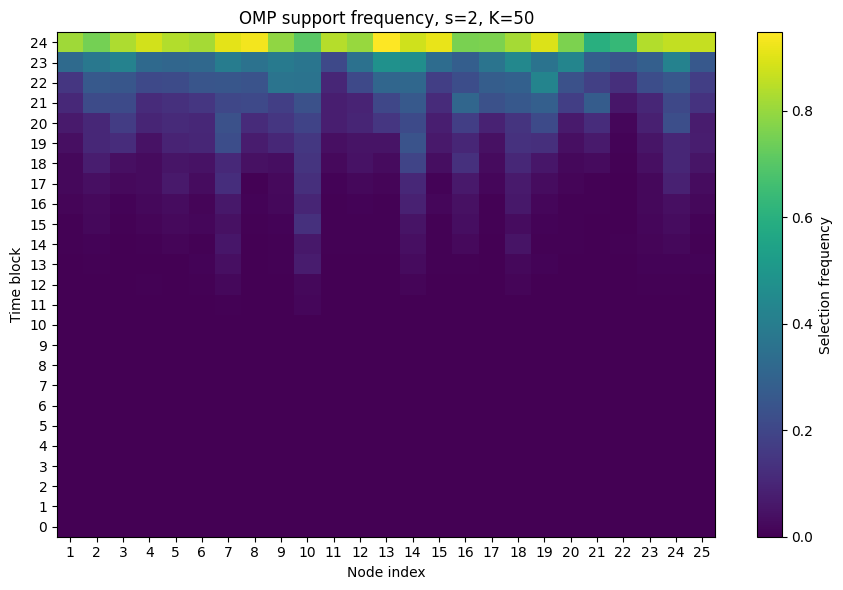

In [185]:
s = 2

_, omp_frequency = support_frequency_from_U(
    omp_results[s]["U_hat"],
    N=N,
    T=T
)

plt.figure(figsize=(9, 6))
plt.imshow(omp_frequency, aspect="auto", origin="lower")
plt.colorbar(label="Selection frequency")

plt.xlabel("Node index")
plt.ylabel("Time block")
plt.title(f"OMP support frequency, s={s}, K={T*s}")

plt.xticks(np.arange(N), np.arange(1, N+1))
plt.yticks(np.arange(T), np.arange(T))

plt.tight_layout()
plt.show()

### Average support per time block

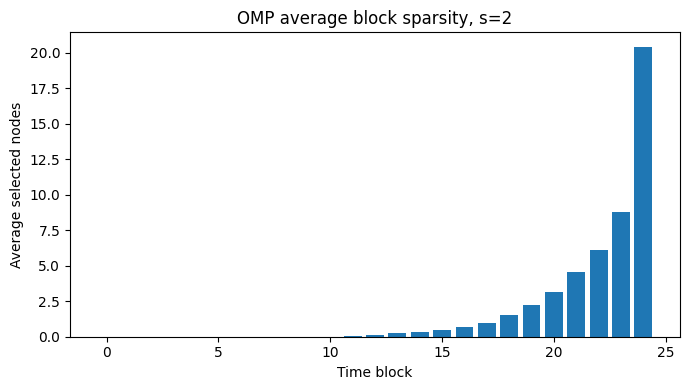

In [186]:
omp_block_usage = omp_frequency.sum(axis=1)

plt.figure(figsize=(7, 4))
plt.bar(np.arange(T), omp_block_usage)

plt.xlabel("Time block")
plt.ylabel("Average selected nodes")
plt.title(f"OMP average block sparsity, s={s}")

plt.tight_layout()
plt.show()

## POMP method

### Helper Functions

In [187]:
def top_k_abs_indices(v, k):
    """Indices of the k largest absolute entries."""
    k = min(k, len(v))
    if k <= 0:
        return np.array([], dtype=int)
    return np.argpartition(np.abs(v), -k)[-k:]


def piecewise_prune(z, s, N=25, T=25):
    """Keep at most s entries inside each time block."""
    z_pruned = np.zeros_like(z)

    for t in range(T):
        start, end = t*N, (t+1)*N
        local_idx = top_k_abs_indices(z[start:end], s)
        z_pruned[start + local_idx] = z[start + local_idx]

    return z_pruned

### POMP implementation

In [188]:
def pomp(Phi, y, s, N=25, T=25, max_iter=None, tol=1e-12):
    """
    Piecewise OMP.

    Enforces:
        ||u_t||_0 <= s  for every time block t.

    The best iterate is returned, since pruning can occasionally increase
    the residual after later iterations.
    """
    if max_iter is None:
        max_iter = s

    n = N * T
    z = np.zeros(n)
    support = np.array([], dtype=int)

    residual = y.copy()
    residual_norms = [np.linalg.norm(residual)]

    best_z = z.copy()
    best_residual_norm = residual_norms[0]

    for _ in range(max_iter):
        proxy = Phi.T @ residual

        new_support = []
        for t in range(T):
            start, end = t*N, (t+1)*N
            local_idx = top_k_abs_indices(proxy[start:end], s)
            new_support.extend(start + local_idx)

        merged_support = np.union1d(support, np.array(new_support))

        Phi_S = Phi[:, merged_support]
        z_S, *_ = np.linalg.lstsq(Phi_S, y, rcond=None)

        z_temp = np.zeros(n)
        z_temp[merged_support] = z_S

        z = piecewise_prune(z_temp, s=s, N=N, T=T)
        support = np.flatnonzero(np.abs(z) > 1e-12)

        residual = y - Phi @ z
        res_norm = np.linalg.norm(residual)
        residual_norms.append(res_norm)

        if res_norm < best_residual_norm:
            best_residual_norm = res_norm
            best_z = z.copy()

        if res_norm <= tol:
            break

    best_support = np.flatnonzero(np.abs(best_z) > 1e-12)

    return best_z, best_support, residual_norms

### Evaluate POMP over all targets

In [189]:
def evaluate_pomp(Xf, C, C_tilde, safe_col_norms, s, N=25, T=25):
    errors = []
    energies = []
    U_hat = []

    for y in Xf:
        z_hat, _, _ = pomp(
            Phi=C_tilde,
            y=y,
            s=s,
            N=N,
            T=T,
            max_iter=s
        )

        u_hat = z_hat / safe_col_norms
        x_hat = C @ u_hat

        errors.append(np.linalg.norm(y - x_hat) / np.linalg.norm(y))
        energies.append(np.linalg.norm(u_hat))
        U_hat.append(u_hat)

    return {
        "errors": np.array(errors),
        "energies": np.array(energies),
        "U_hat": np.array(U_hat),
    }

### POMP sparsity sweep

In [190]:
s_values = [1, 2, 3, 4, 5]
pomp_results = {}

for s in s_values:
    res = evaluate_pomp(Xf, C, C_tilde, safe_col_norms, s, N=N, T=T)
    pomp_results[s] = res

    print(f"\nPOMP, s={s}")
    print("-----------")
    print("Mean error :", res["errors"].mean())
    print("Median error:", np.median(res["errors"]))
    print("Max error  :", res["errors"].max())
    print("Mean energy:", res["energies"].mean())


POMP, s=1
-----------
Mean error : 1.524636807382988e-08
Median error: 1.5899509834827092e-09
Max error  : 3.2074960862308963e-06
Mean energy: 57.04457257795559

POMP, s=2
-----------
Mean error : 1.0358524070530953e-13
Median error: 6.48158196220386e-14
Max error  : 1.5286562730199153e-12
Mean energy: 10.194752424016153

POMP, s=3
-----------
Mean error : 9.168900199116537e-15
Median error: 7.382903327278192e-15
Max error  : 1.5547687021895636e-13
Mean energy: 7.962602457413085

POMP, s=4
-----------
Mean error : 4.158063911221881e-15
Median error: 3.6817516770849e-15
Max error  : 1.8964010864153693e-14
Mean energy: 6.5780748496226185

POMP, s=5
-----------
Mean error : 3.340619015290686e-15
Median error: 2.9433001470491525e-15
Max error  : 1.0963947718093174e-14
Mean energy: 5.768571171005437


### Verify piecewise constraint

In [191]:
for s in s_values:
    block_counts = block_sparsity_counts(pomp_results[s]["U_hat"], N=N, T=T)

    print(f"\nPOMP block distribution, s={s}")
    print("----------------------------")
    print("Mean total sparsity:", block_counts.sum(axis=1).mean())
    print("Mean block sparsity:", block_counts.mean())
    print("Mean max block sparsity:", block_counts.max(axis=1).mean())
    print("Largest observed block sparsity:", block_counts.max())


POMP block distribution, s=1
----------------------------
Mean total sparsity: 22.318
Mean block sparsity: 0.89272
Mean max block sparsity: 1.0
Largest observed block sparsity: 1

POMP block distribution, s=2
----------------------------
Mean total sparsity: 32.887
Mean block sparsity: 1.31548
Mean max block sparsity: 2.0
Largest observed block sparsity: 2

POMP block distribution, s=3
----------------------------
Mean total sparsity: 43.686
Mean block sparsity: 1.74744
Mean max block sparsity: 3.0
Largest observed block sparsity: 3

POMP block distribution, s=4
----------------------------
Mean total sparsity: 54.605
Mean block sparsity: 2.1842
Mean max block sparsity: 4.0
Largest observed block sparsity: 4

POMP block distribution, s=5
----------------------------
Mean total sparsity: 65.34
Mean block sparsity: 2.6136
Mean max block sparsity: 5.0
Largest observed block sparsity: 5


### POMP support heatmap

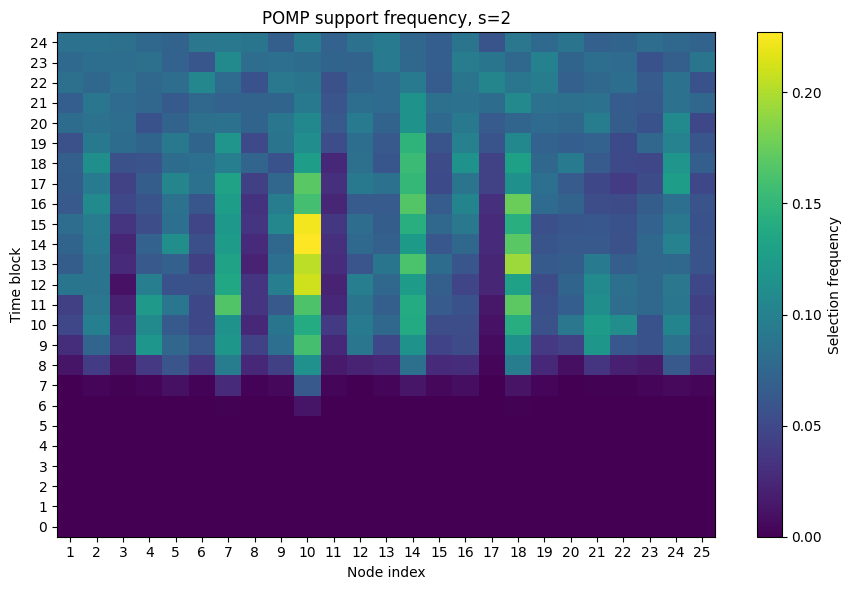

In [192]:
s = 2

_, pomp_frequency = support_frequency_from_U(
    pomp_results[s]["U_hat"],
    N=N,
    T=T
)

plt.figure(figsize=(9, 6))
plt.imshow(pomp_frequency, aspect="auto", origin="lower")
plt.colorbar(label="Selection frequency")

plt.xlabel("Node index")
plt.ylabel("Time block")
plt.title(f"POMP support frequency, s={s}")

plt.xticks(np.arange(N), np.arange(1, N+1))
plt.yticks(np.arange(T), np.arange(T))

plt.tight_layout()
plt.show()

## SBL / block SBL